# Data

The aim of this notebook is to create a dataset of Rice assets.

In this notebook we follow the different steps:
1. Library Importation
2. Data Importation
3. Data Exploration
4. Data Cleaning
5. Data Saving

## 1. Library Importation

In [50]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np

## 2. Data Importation

All data are obtained from the yfinance API.

**The Primary Anchor (1 asset)**: 

- rough rice futures

**The Sector Proxies (4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA
- iPath Bloomberg Grains ETN, JJG
- Elements Rogers International Agriculture ETN, RJA
- WisdomTree Grains ETF, 1688.T

**The Individual Universe (17 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM – Global agribusiness and grain trading company
- Bunge Global SA, BG – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI  – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF  – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP – Global agricultural company involved in food production and distribution
- Yara International ASA, YAR.OL – Norwegian fertilizer company playing a key role in global agricultural productivity
- Ingredion Incorporated, INGR – US-based producer of starches and food ingredients derived from agricultural commodities
- Itochu Corporation, 8001.T – Japanese trading house with strong involvement in global agricultural and food supply chains
- BrasilAgro – Companhia Brasileira de Propriedades Agrícolas, AGRO3.SA (yfinance) – Brazilian company focused on farmland development and agricultural production


In [51]:

anchor = [
    "ZR=F"
]


sector_proxies = [
    "DBA",         
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP",
    "YAR.OL",   
    "INGR",     
    "8001.T",   
    "AGRO3.SA" 
]

In [53]:
tickers = anchor + sector_proxies + companies


data = yf.download(tickers, start="2018-01-01", end="2026-03-28", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T      8001.T        ADM      AGRO  AGRO3.SA         BG  \
Date                                                                       
2018-01-01   395.0  326.628387        NaN       NaN       NaN        NaN   
2018-01-02   395.0  326.628387  31.407618  9.198833  6.842368  52.966415   
2018-01-03   395.0  326.628387  31.164761  9.394551  6.836969  54.103798   
2018-01-04   399.0  334.860168  31.689669  9.350069  7.058386  54.898426   
2018-01-05   390.0  337.034546  31.478142  9.207728  7.204200  54.485538   

Ticker             CF  CLSEL.NS        DBA        FDP        INGR     KRBL.NS  \
Date                                                                            
2018-01-01        NaN       NaN        NaN        NaN         NaN  556.974548   
2018-01-02  35.073044       NaN  16.306484  39.298061  111.920692  555.493774   
2018-01-03  35.081184       NaN  16.297888  39.524158  110.449440  560.167542   
2018-01-04  35.447037       NaN  16.272102  40.353149  112.624

In [ ]:
#anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
#anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
#anchor = anchor.set_index("Date")

#anchor_close = anchor["Dernier"].rename("Futures")

anchor_close = anchor["Close"]

close_prices = close_prices.join(anchor_close)

df_raw = close_prices.copy()
df_raw = df_raw.rename(columns={"ZR=F": "Futures"})

## 3. Data Exploration

This step aims to give a clear overview of the raw data. This overview will be particularly useful to understand the data and prepare the cleaning part.

In [ ]:
def plot_missing_proportions(
    df: pd.DataFrame,
    title: str = "Missing value proportion by asset"
) -> pd.Series:
    """
    Plot the proportion of missing values for each column in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    title : str
        Plot title.

    Returns
    -------
    pd.Series
        Missing value proportions by column.
    """
    if df.empty:
        raise ValueError("The input DataFrame is empty.")

    missing_prop = df.isna().mean().sort_values(ascending=False)

    ax = missing_prop.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title)
    ax.set_xlabel("Assets")
    ax.set_ylabel("Missing value proportion")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)

    for i, value in enumerate(missing_prop):
        ax.text(i, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return missing_prop

def price_visualization(df: pd.DataFrame, title: str = "Asset price trends") -> None:
    # Normalize all prices to 100 at the start of the period for comparison.
    first_valid = df.apply(lambda col: col[col.notna()].iloc[0])
    df_norm = df / first_valid * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # --- Plot 1: Raw prices ---
    for col in df.columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
    axes[0].set_title('Raw Prices (2020–2026)', fontsize=13)
    axes[0].set_ylabel('Price (USD or local currency)')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # --- Plot 2: Normalized prices (rebased to 100) ---
    for col in df_norm.columns:
        axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
    axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title('Normalized Prices (rebased to 100 at start)', fontsize=13)
    axes[1].set_ylabel('Index (base = 100)')
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [ ]:
df_raw

Ticker,1688.T,8001.T,ADM,AGRO,AGRO3.SA,BG,CF,CLSEL.NS,DBA,FDP,INGR,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,YAR.OL,Futures
Date,,,,,,,,,,,,,,,,,,,,
2018-01-01,395.000000,326.628510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,556.974609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,395.000000,326.628510,31.407621,9.198831,6.842369,52.966423,35.073044,NaN,16.306486,39.298054,111.920723,555.493774,NaN,23.238760,41.927891,6.06,1.330320,NaN,228.992294,1153.5
2018-01-03,395.000000,326.628510,31.164764,9.394552,6.836969,54.103809,35.081181,NaN,16.297888,39.524162,110.449417,560.167542,NaN,23.029480,42.395027,6.08,1.310757,NaN,231.166885,1141.0
2018-01-04,399.000000,334.860168,31.689661,9.350071,7.058387,54.898426,35.447033,NaN,16.272100,40.353149,112.624374,566.276001,NaN,23.386999,42.540527,6.08,1.330320,NaN,230.623215,1147.5
2018-01-05,390.000000,337.034546,31.478128,9.207728,7.204199,54.485542,35.503929,NaN,16.186140,40.361534,112.208557,577.104492,NaN,23.421881,42.678368,6.04,1.330320,NaN,232.797775,1156.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,590.000000,1959.500000,67.989998,13.190000,20.860001,120.820000,120.180000,221.500000,26.840000,41.970001,110.449997,285.200012,364.000000,24.080000,72.860001,NaN,0.845000,2.68,493.600006,1093.5
2026-03-24,569.900024,2029.500000,71.440002,13.970000,20.770000,124.089996,126.919998,225.850006,26.889999,42.549999,110.059998,296.350006,379.049988,25.200001,76.820000,NaN,0.845000,2.81,519.400024,1099.0
2026-03-25,567.500000,2078.500000,71.660004,14.700000,20.430000,125.400002,128.110001,228.199997,26.959999,42.480000,110.790001,303.100006,384.049988,26.190001,76.620003,NaN,0.845000,2.85,528.200012,1097.5


In [ ]:
print(f"Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} trading days, {df_raw.shape[1]} assets)")
print(f"Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print()
print("Columns (assets):")
print(list(df_raw.columns))

Dataset shape: (2153, 20)  (2153 trading days, 20 assets)
Date range: 2018-01-01 → 2026-03-27

Columns (assets):
['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'CLSEL.NS', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'LTFOODS.NS', 'MOS', 'NTR', 'RJA', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']


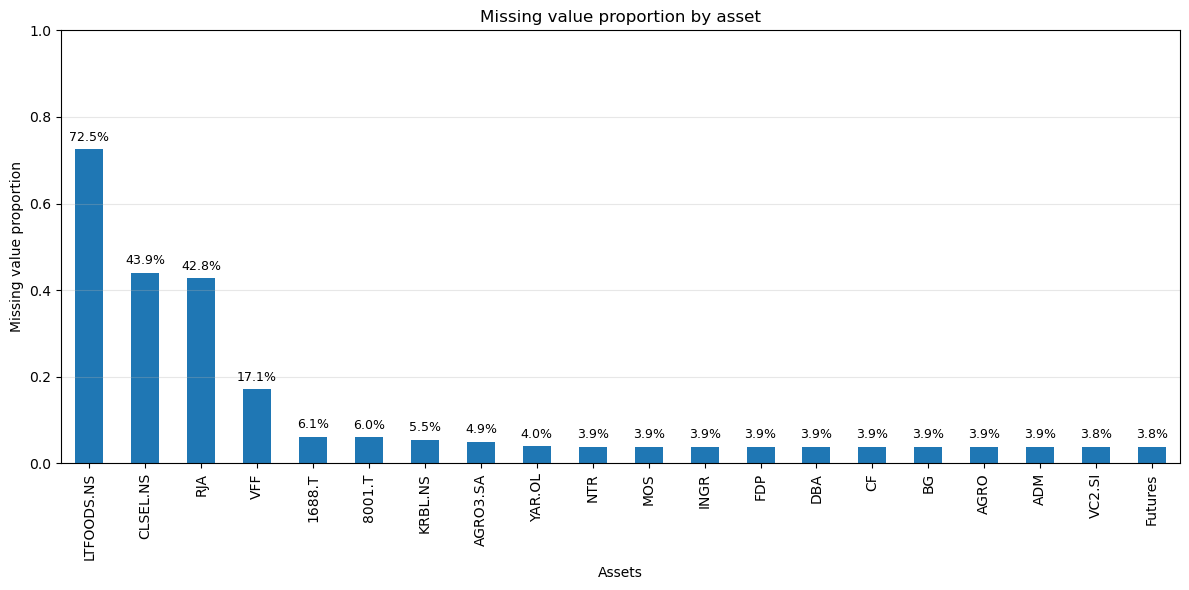

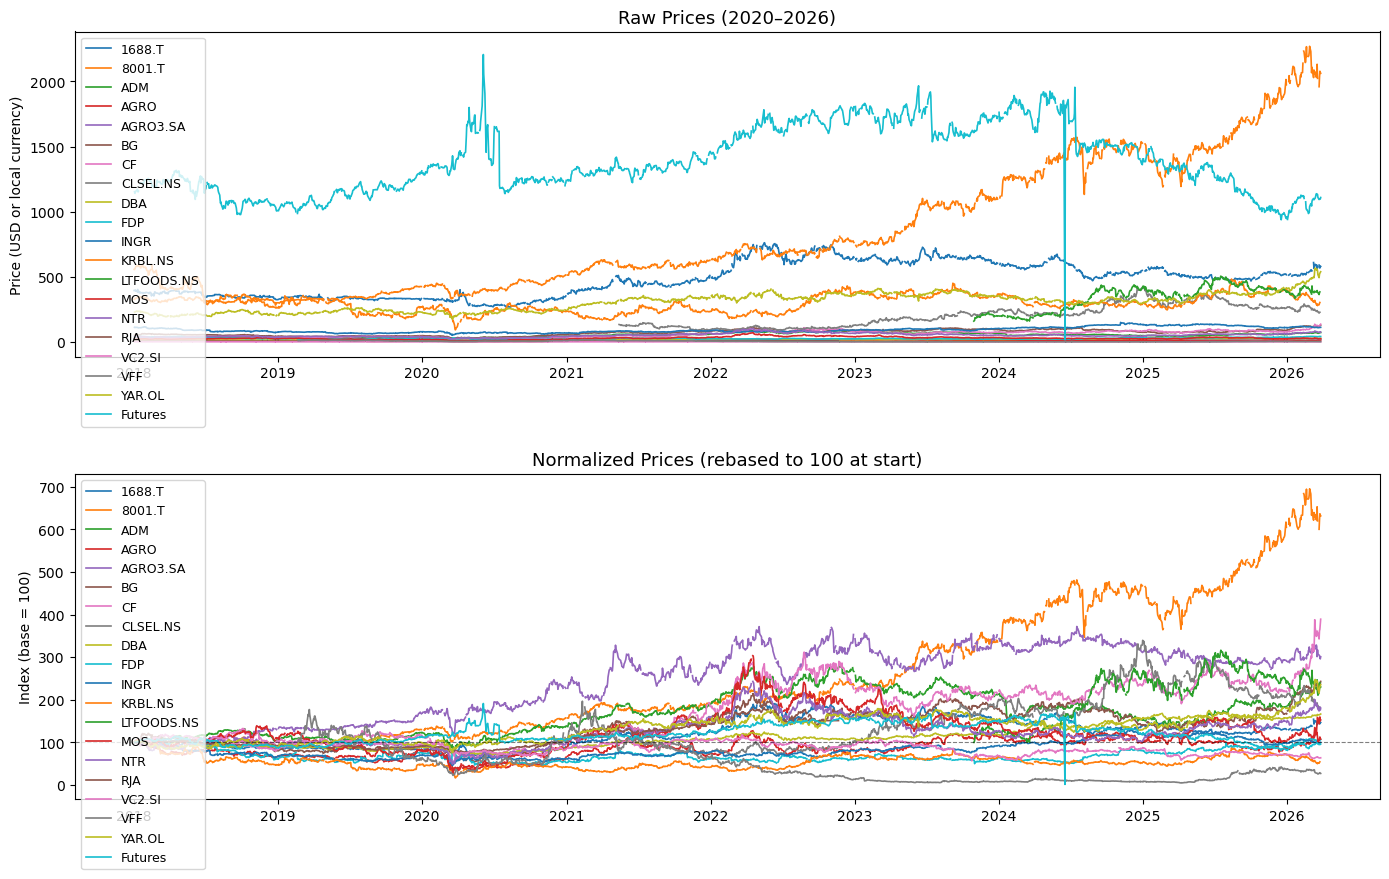

In [ ]:
plot_missing_proportions(df_raw)
price_visualization(df_raw)

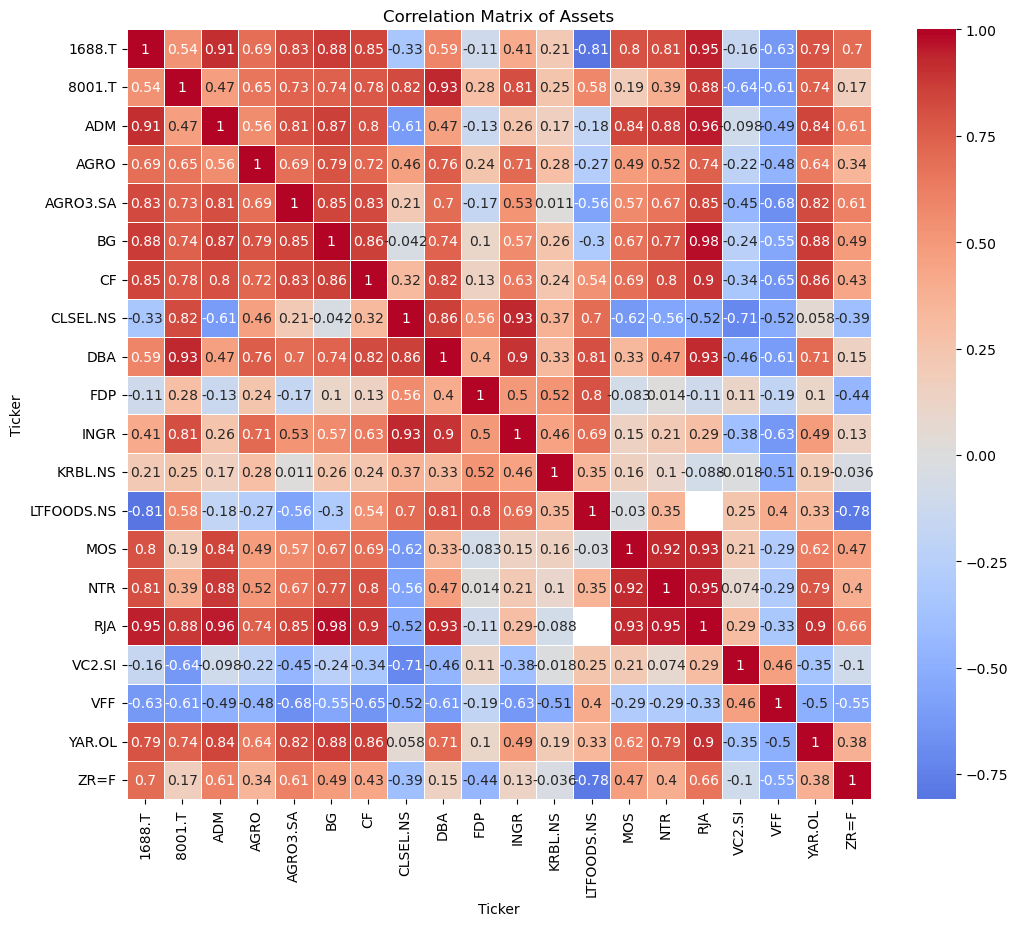

In [ ]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()

# 4. Data Cleaning

In [ ]:
# ==========================
# GLOBAL VARIABLES
# ==========================

START = '2018-01-01'

### 4.1 Keep rows where the Futures is available

`Futures` variable contains NaN values up until 2020. Thus we will start our dataset from this date. Having values up to 2026. We still keep more than 5 years of data in our dataset. 

In [ ]:
# ==========================
# DATA CLEANING
# ==========================

ANCHOR = 'Futures'
df = df_raw[df_raw[ANCHOR].notna()].copy()
df = df[df.index >= START]

print(f"After anchor filter — shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print()

After anchor filter — shape: (2071, 20)
Date range: 2018-01-02 → 2026-03-27



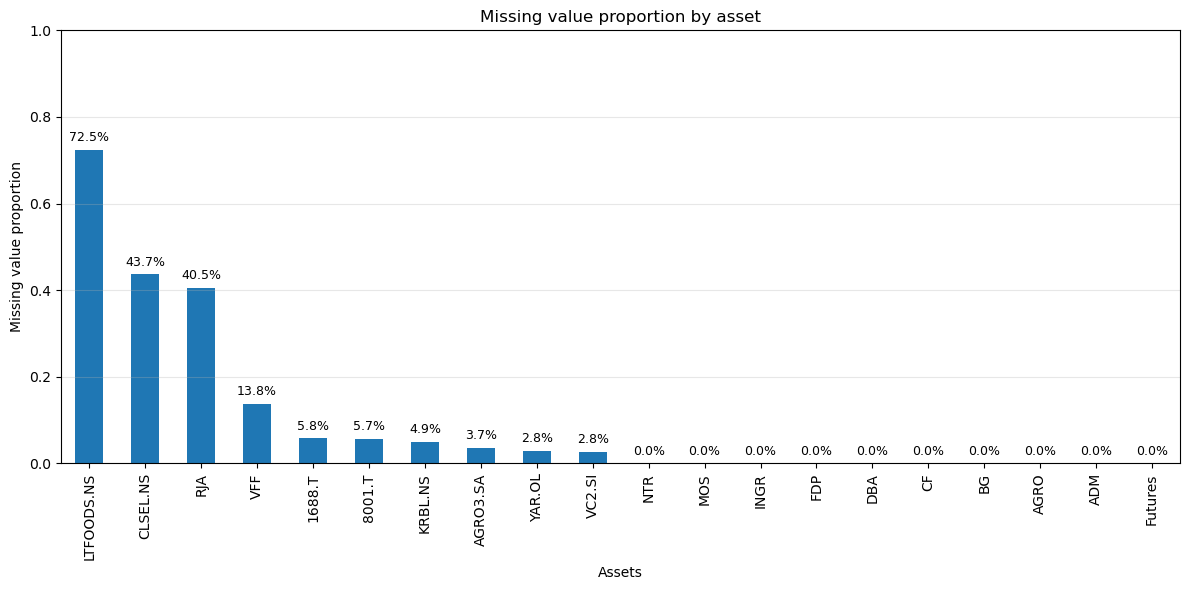

Ticker
LTFOODS.NS    0.724771
CLSEL.NS      0.436987
RJA           0.405118
VFF           0.138098
1688.T        0.058426
8001.T        0.057460
KRBL.NS       0.049252
AGRO3.SA      0.036697
YAR.OL        0.028489
VC2.SI        0.027523
NTR           0.000483
MOS           0.000483
INGR          0.000483
FDP           0.000483
DBA           0.000483
CF            0.000483
BG            0.000483
AGRO          0.000483
ADM           0.000483
Futures       0.000000
dtype: float64

In [ ]:
plot_missing_proportions(df)

### 4.2 Drop assets with more than 20% missing values

In [ ]:
MISSING_THRESHOLD = 0.20
missing_pct = df.isnull().mean()
print("Missing value rate per asset:")
print(missing_pct.round(4).to_frame('Missing %').to_string())
print()

assets_to_keep = missing_pct[missing_pct <= MISSING_THRESHOLD].index.tolist()
assets_dropped = missing_pct[missing_pct >  MISSING_THRESHOLD].index.tolist()

print(f"Assets dropped (>{MISSING_THRESHOLD*100:.0f}% missing): {assets_dropped}")
print(f"Assets retained for screening: {assets_to_keep}")
print()

df = df[assets_to_keep].copy()

Missing value rate per asset:
            Missing %
Ticker               
1688.T         0.0584
8001.T         0.0575
ADM            0.0005
AGRO           0.0005
AGRO3.SA       0.0367
BG             0.0005
CF             0.0005
CLSEL.NS       0.4370
DBA            0.0005
FDP            0.0005
INGR           0.0005
KRBL.NS        0.0493
LTFOODS.NS     0.7248
MOS            0.0005
NTR            0.0005
RJA            0.4051
VC2.SI         0.0275
VFF            0.1381
YAR.OL         0.0285
Futures        0.0000

Assets dropped (>20% missing): ['CLSEL.NS', 'LTFOODS.NS', 'RJA']
Assets retained for screening: ['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']



### 4.3 Forward-fill remaining NaNs

In [ ]:
# Step 3: Forward-fill remaining NaNs (align trading days across markets)
# then drop any residual NaN rows
df = df.ffill().dropna()

# Make sure the anchor is still present
assert ANCHOR in df.columns, f"ERROR: Anchor '{ANCHOR}' was dropped — lower MISSING_THRESHOLD."

ALL_ASSETS = list(df.columns)   # full universe passed to screening

print(f"All selected assets for Section 3 screening: {ALL_ASSETS}")

All selected assets for Section 3 screening: ['1688.T', '8001.T', 'ADM', 'AGRO', 'AGRO3.SA', 'BG', 'CF', 'DBA', 'FDP', 'INGR', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'YAR.OL', 'Futures']


### 4.4 Outliers

### Why handle the outliers?

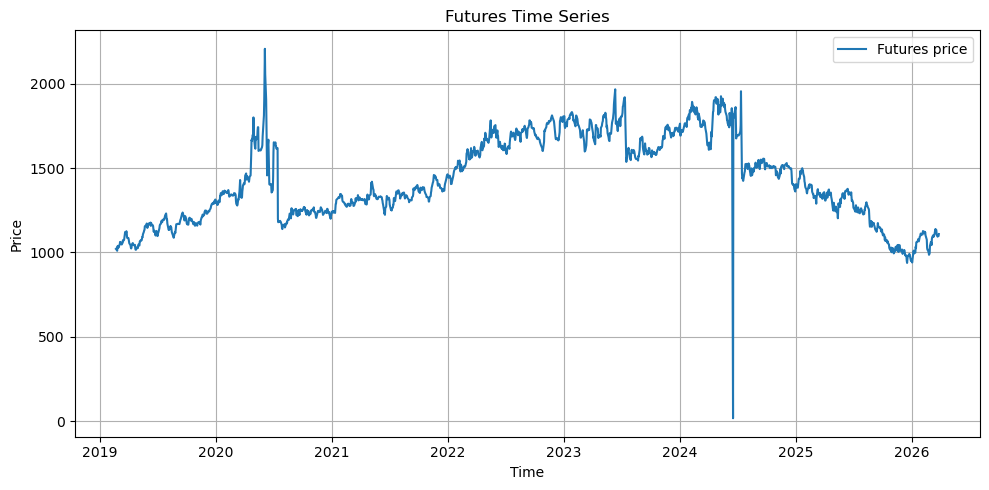

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df["Futures"], label="Futures price")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Futures Time Series")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

As we can observe, there are some abnormal price variations, such as in 2024 where the futures price drops close to zero. Such anomalies can have a significant and unrealistic impact on trading strategies.

To address this issue, we identify several types of outliers:

- extrem absolute returns (above 50%),
- price glitches, such as isolated patterns where the price moves from 1000 to 0 and then returns to 1000.

After detecting these outlier, and in order to preserve the overall price dynamics, we correct them by replacing the abnormal value with the average of the surrounding prices (the prices immediately before and after the outlier).

The following code implements this procedure.

In [ ]:
def clean_price(price, max_return=0.5):
    
    price = price.copy()
    
    returns = price.pct_change()
    outlier_mask = np.abs(returns) > max_return
    
    for i in range(1, len(price)-1):
        
        if outlier_mask.iloc[i]:
            
            prev_p = price.iloc[i-1]
            next_p = price.iloc[i+1]
            
            if np.isfinite(prev_p) and np.isfinite(next_p) and prev_p > 0 and next_p > 0:
                
                price.iloc[i] = (prev_p + next_p) / 2
    
    return price

In [ ]:
df = df.apply(clean_price)

### 4.5 Price visualization

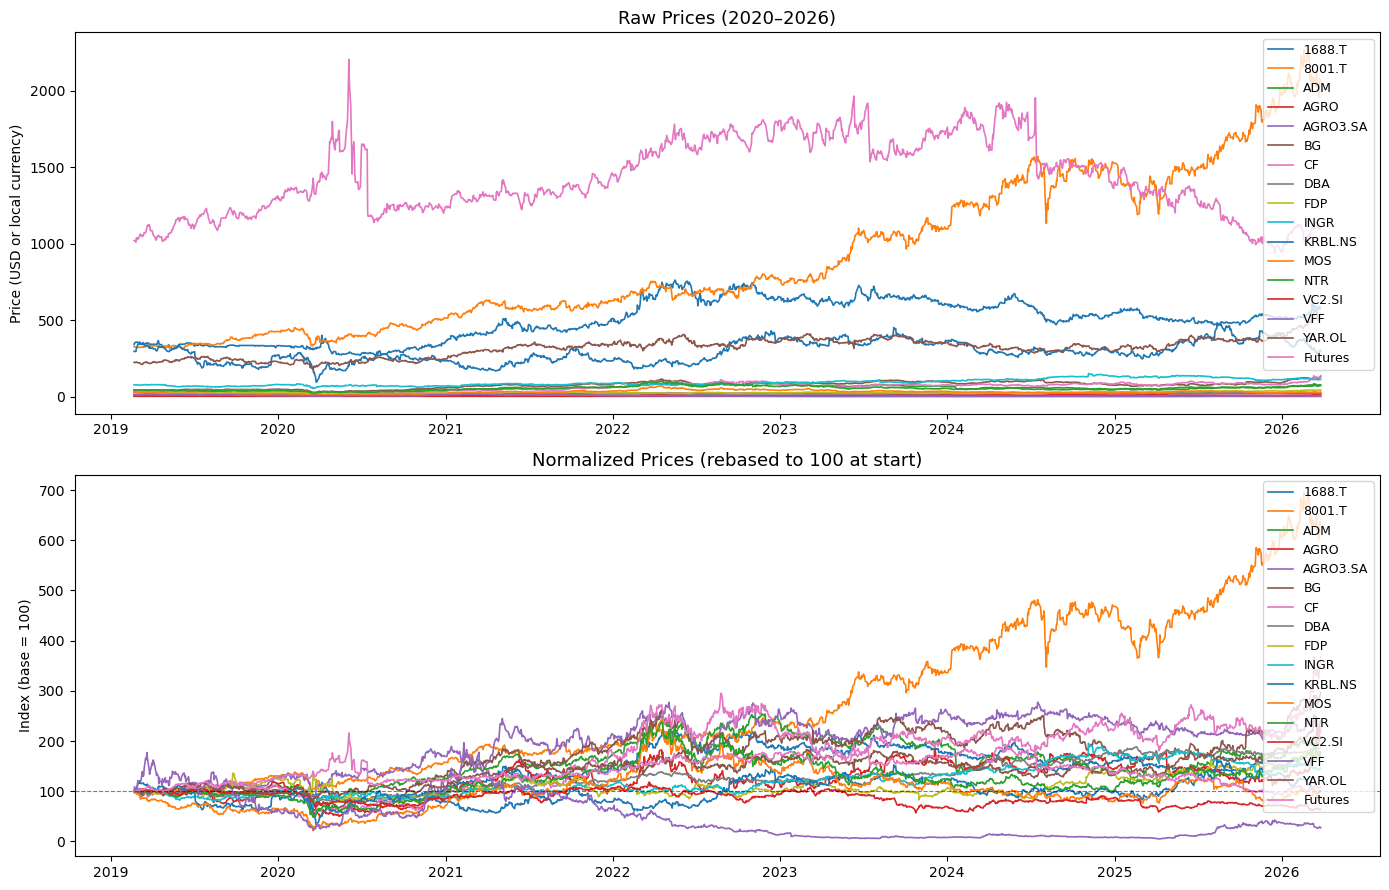

In [ ]:
price_visualization(df)

# 5. Data Saving

In [ ]:
df.to_csv("data.csv")